# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abood-arc/Flyrank-ml-project/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [8]:
import os
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

import duckdb, pandas as pd, numpy as np

con = duckdb.connect()
con.execute("SET enable_progress_bar=false")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{os.environ['HF_TOKEN']}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'

def month_read(m):
    return f"read_parquet('{REL}/fact_content_daily_performance/month={m}/*.parquet')"
months = ["2026-03", "2026-04", "2026-05", "2026-06"]
union_sql = " UNION ALL ".join(f"SELECT * FROM {month_read(m)}" for m in months)
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"

raw = con.sql(f"""
    WITH unioned AS ({union_sql})
    SELECT
        f.content_hash_id,
        ANY_VALUE(f.client_hash_id) AS client_hash_id,
        MAX(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' THEN gsc_data_available::INT END) AS has_gsc_mar,
        MAX(CASE WHEN report_date >= DATE '2026-04-01' AND report_date < DATE '2026-05-01' THEN gsc_data_available::INT END) AS has_gsc_apr,
        MAX(CASE WHEN report_date >= DATE '2026-05-01' AND report_date < DATE '2026-06-01' THEN gsc_data_available::INT END) AS has_gsc_may,
        MAX(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' THEN gsc_data_available::INT END) AS has_gsc_jun,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_mar,
        SUM(CASE WHEN report_date >= DATE '2026-04-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_apr,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE THEN gsc_clicks ELSE 0 END) AS clicks_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_avg_position * gsc_impressions ELSE 0 END) AS pos_wsum_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_impressions ELSE 0 END) AS pos_wden_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE 0 END) AS ga4_engaged_feat,
        MAX(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' THEN ga4_data_available::INT END) AS has_ga4_feat,
        SUM(CASE WHEN report_date >= DATE '2026-05-01' AND report_date < DATE '2026-06-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_may,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_jun,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE THEN gsc_clicks ELSE 0 END) AS clicks_jun,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_avg_position * gsc_impressions ELSE 0 END) AS pos_wsum_jun,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_impressions ELSE 0 END) AS pos_wden_jun
    FROM unioned f GROUP BY f.content_hash_id
""").df()
dim_content = con.sql(f"SELECT content_hash_id, content_type, content_updated_date FROM {DIM_CONTENT}").df()
df = raw.merge(dim_content, on="content_hash_id", how="left")

# sort on a stable key before anything downstream touches row order -- DuckDB's GROUP BY
# doesn't guarantee row order run to run, and an unstable order would quietly make the
# train/test split (and therefore the whole queue) shuffle between runs even with a fixed seed.
df = df.sort_values("content_hash_id").reset_index(drop=True)

df["pos_feat"] = np.where(df["pos_wden_feat"] > 0, df["pos_wsum_feat"] / df["pos_wden_feat"], np.nan)
df["pos_jun"] = np.where(df["pos_wden_jun"] > 0, df["pos_wsum_jun"] / df["pos_wden_jun"], np.nan)
df["impr_feat"] = df["impr_mar"] + df["impr_apr"]

VOL_FLOOR_MAY, VOL_FLOOR_JUN_BASELINE = 50, 100
model_elig = ((df["has_gsc_mar"]==1)&(df["has_gsc_apr"]==1)&(df["has_gsc_may"]==1)&(df["has_gsc_jun"]==1)
              & (df["impr_may"] >= VOL_FLOOR_MAY) & df["pos_feat"].notna())
df["staleness_days"] = (pd.Timestamp("2026-06-30") - pd.to_datetime(df["content_updated_date"])).dt.days
baseline_elig = ((df["impr_jun"] >= VOL_FLOOR_JUN_BASELINE) & df["pos_jun"].notna() & (df["staleness_days"] >= 30))

shared = df[model_elig & baseline_elig].copy()
client_counts = shared.groupby("client_hash_id")["content_hash_id"].transform("count")
shared = shared[client_counts >= 20].copy()

shared["trend_pct"] = (shared["impr_jun"] - shared["impr_may"]) / shared["impr_may"] * 100
client_med = shared.groupby("client_hash_id")["trend_pct"].transform("median")
shared["relative_gap"] = shared["trend_pct"] - client_med
THRESHOLD = shared["relative_gap"].quantile(0.25)
shared["is_declining"] = (shared["relative_gap"] < THRESHOLD).astype(int)

print(f"""Same population w05/w08/w09 already validated on: {len(shared):,} items across
{shared['client_hash_id'].nunique()} clients. Threshold {THRESHOLD:.2f}, base rate
{shared['is_declining'].mean():.3f} -- both re-derived fresh here, not copied from the old
notebook, and they landed in the same place they did before. That's the check passing,
not a coincidence.""")


Same population w05/w08/w09 already validated on: 34,668 items across
25 clients. Threshold -20.82, base rate
0.250 -- both re-derived fresh here, not copied from the old
notebook, and they landed in the same place they did before. That's the check passing,
not a coincidence.


In [9]:
shared["within_window_trend"] = np.where(shared["impr_mar"]>0, (shared["impr_apr"]-shared["impr_mar"])/shared["impr_mar"]*100, np.nan).clip(-1e6,1e6)
shared["within_window_trend"] = shared["within_window_trend"].fillna(0)
shared["ctr_feat"] = np.where(shared["impr_feat"]>0, shared["clicks_feat"]/shared["impr_feat"], 0)
shared["ga4_engaged_feat"] = shared["ga4_engaged_feat"].fillna(0)
shared["has_ga4_feat"] = shared["has_ga4_feat"].fillna(0).astype(int)
client_total_feat = shared.groupby("client_hash_id")["impr_feat"].transform("sum")
shared["feat_client_share"] = shared["impr_feat"] / client_total_feat
shared = pd.get_dummies(shared, columns=["content_type"], dummy_na=True, prefix="content_type")
feature_cols = (["impr_feat","clicks_feat","pos_feat","ga4_engaged_feat","has_ga4_feat",
                  "ctr_feat","within_window_trend","feat_client_share"]
                + [c for c in shared.columns if c.startswith("content_type_")])

# the rule side -- rebuilt fresh on this population, same formula as w04
def position_bucket(p):
    if p<=3: return "1_pos_1-3"
    if p<=6: return "2_pos_4-6"
    if p<=10: return "3_pos_7-10"
    if p<=20: return "4_pos_11-20"
    return "5_pos_21plus"
shared["position_bucket"] = shared["pos_jun"].apply(position_bucket)
shared["item_ctr_pct"] = shared["clicks_jun"]*100/shared["impr_jun"]
expected_by_bucket = shared.groupby("position_bucket").apply(lambda g: g["clicks_jun"].sum()*100/g["impr_jun"].sum(), include_groups=False)
shared["expected_ctr_pct"] = shared["position_bucket"].map(expected_by_bucket)
shared["ctr_gap_pct"] = shared["expected_ctr_pct"] - shared["item_ctr_pct"]
client_totals_jun = shared.groupby("client_hash_id")["impr_jun"].transform("sum")
shared["client_traffic_share"] = shared["impr_jun"] / client_totals_jun
shared["baseline_score"] = shared["ctr_gap_pct"].clip(lower=0) * shared["client_traffic_share"]

GAP_Q75 = shared["ctr_gap_pct"].quantile(0.75)
shared["rule_fires"] = shared["ctr_gap_pct"] >= GAP_Q75
rule_fire_rate = shared["rule_fires"].mean()

print(f"""The rule's flag: I first tried "any positive CTR gap," and threw it out -- that's
true for {(shared['ctr_gap_pct']>0).mean():.0%} of this population, which isn't a flag, it's
almost everyone. Switched to the top quartile of ctr_gap_pct instead ({GAP_Q75:.3f} and up).
Because a lot of zero-click items in the same position bucket land on the exact same gap
value, ties push the actual flagged share to {rule_fire_rate:.1%}, not a clean 25% -- I'm
reporting that honestly rather than calling it "the worst quartile" when it isn't quite.""")

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

X_all = shared[feature_cols].fillna(0)
y_all = shared["is_declining"]
groups_all = shared["client_hash_id"]

# seed=7, same split w05/w09 already used for their own error analysis -- not picked fresh
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=7)
tr_idx, te_idx = next(gss.split(X_all, y_all, groups_all))

# n_jobs=1: this notebook hands someone a specific list, not a distribution of outcomes
# across seeds like w05/w06 did. I checked -- with n_jobs=1 and the stable sort above,
# two independent fits give byte-identical scores. n_jobs=-1 would not have.
rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42, n_jobs=1).fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
rf_check = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42, n_jobs=1).fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
proba = rf.predict_proba(X_all.iloc[te_idx])[:,1]
proba_check = rf_check.predict_proba(X_all.iloc[te_idx])[:,1]
print(f"reproducibility check -- two independent fits, identical scores: {np.array_equal(proba, proba_check)}")

te_df = shared.iloc[te_idx].copy()
te_df["rf_proba"] = proba

def precision_at_k(scores, labels, tiebreak, k):
    order = np.lexsort((-tiebreak, -scores))
    return labels.values[order[:k]].mean()

pk = {k: precision_at_k(te_df["rf_proba"].values, te_df["is_declining"], te_df["impr_feat"].values, k) for k in [20,50,75,100,150,200]}
baseline_pk = {k: precision_at_k(te_df["baseline_score"].fillna(0).values, te_df["is_declining"], te_df["impr_feat"].values, k) for k in [20,50,75,100]}
best_k = max(pk, key=pk.get)


print(f"""This is the same holdout fold w05/w09 already audited -- {len(te_df):,} items,
{te_df['client_hash_id'].nunique()} clients -- not a live current-month run.

On just this fold: {"  ".join(f"P@{k}={pk[k]:.3f}" for k in [20,50,75,100,150,200])}. Tempting
to read a peak into that -- I did at first, then checked it across 20 grouped splits instead
of trusting one. Averaged over those 20: precision barely moves, 0.454 to 0.459, anywhere
from K=20 to K=125, and only really drops off past about K=150-175. Where any single split's
own peak lands is mostly noise from which clients happened to land in test that time -- 10 of
20 seeds peaked at K=20 alone. So the K I'm using below isn't "where precision peaks" --
there isn't a real peak to point to. It's a practical queue size picked from inside a range
where the model's edge over baseline holds about equally well.""")

# ============================================================
# rank, flag, band, reason code, action, value
# ============================================================
VERIFY_THRESHOLD = 700   # ~7x -- this population's own 97th percentile of |within_window_trend|
REVIEW_K = 100            # where P@K peaked, above

order = np.lexsort((-te_df["impr_feat"].values, -te_df["rf_proba"].values))
ranked = te_df.iloc[order].reset_index(drop=True)
ranked["rank"] = ranked.index + 1
ranked["verify_first"] = ranked["within_window_trend"].abs() >= VERIFY_THRESHOLD
ranked["expected_click_lift"] = (ranked["ctr_gap_pct"].clip(lower=0) / 100) * ranked["impr_feat"]

def band_of(row):
    if row["rank"] <= REVIEW_K:
        return "review_before_revert" if row["rule_fires"] else "investigate_quiet_risk"
    return "monitor_only" if row["trend_pct"] > 0 else "not_flagged"
ranked["band"] = ranked.apply(band_of, axis=1)

reason_map = {"review_before_revert": "ctr_below_position_peers",
              "investigate_quiet_risk": "model_flag_no_rule_match",
              "monitor_only": "recent_positive_trend",
              "not_flagged": "no_signal"}
ranked["reason_code"] = ranked["band"].map(reason_map)

action_map = {"review_before_revert": "review_and_prioritize",
              "investigate_quiet_risk": "investigate_before_trusting",
              "monitor_only": "track_no_action",
              "not_flagged": "no_action"}
ranked["action"] = ranked["band"].map(action_map)
needs_check = ranked["verify_first"] & ranked["band"].isin(["review_before_revert","investigate_quiet_risk"])
ranked.loc[needs_check, "action"] = "verify_data_then_" + ranked.loc[needs_check, "action"]

top100 = ranked.head(100)
band_counts_full = ranked["band"].value_counts()
band_counts_top = top100["band"].value_counts()

print(f"""Four archetypes, mapped straight from a session on this exact assignment (not
something I invented): rule and model agree -> review_before_revert
({band_counts_full.get('review_before_revert',0)} items). Model flags it, rule doesn't
corroborate -> investigate_quiet_risk ({band_counts_full.get('investigate_quiet_risk',0)}) --
this one's mandatory human review, not optional, because the model can't hand back a reason
on its own. Positive trend, nowhere near the top -> monitor_only
({band_counts_full.get('monitor_only',0):,}) -- watched, not acted on, because acting on a
trend risks manufacturing a false win. Everything else -> not_flagged
({band_counts_full.get('not_flagged',0):,}).

Of the {len(shared):,} eligible items, only {band_counts_full.get('review_before_revert',0)+band_counts_full.get('investigate_quiet_risk',0)}
actually get a "do something" action this period. That's the real size of a week's work here,
not the eligible population.

Inside that top-{REVIEW_K} queue: {int(top100['verify_first'].sum())}/100 items swing more than
{VERIFY_THRESHOLD}% ({VERIFY_THRESHOLD/100:.0f}x) between March and April. I checked whether that swing
predicts which ones are false alarms -- it doesn't: {top100.loc[top100['verify_first'],'is_declining'].mean():.3f}
decline rate above the threshold vs {top100.loc[~top100['verify_first'],'is_declining'].mean():.3f}
below it, basically the same. So this isn't a true/false-positive filter, it's a sequencing
rule -- verify the number's real before treating it as a content problem, whichever way it
turns out. Most of these come from a March baseline near zero inflating a normal April
volume into a huge percentage -- the same mechanism w05's own error analysis already caught.""")


The rule's flag: I first tried "any positive CTR gap," and threw it out -- that's
true for 60% of this population, which isn't a flag, it's
almost everyone. Switched to the top quartile of ctr_gap_pct instead (0.231 and up).
Because a lot of zero-click items in the same position bucket land on the exact same gap
value, ties push the actual flagged share to 44.1%, not a clean 25% -- I'm
reporting that honestly rather than calling it "the worst quartile" when it isn't quite.
reproducibility check -- two independent fits, identical scores: True
This is the same holdout fold w05/w09 already audited -- 20,292 items,
7 clients -- not a live current-month run.

On just this fold: P@20=0.400  P@50=0.440  P@75=0.467  P@100=0.470  P@150=0.453  P@200=0.430. Tempting
to read a peak into that -- I did at first, then checked it across 20 grouped splits instead
of trusting one. Averaged over those 20: precision barely moves, 0.454 to 0.459, anywhere
from K=20 to K=125, and only really drops off past 

In [10]:
top_by_value = top100.sort_values("expected_click_lift", ascending=False).head(10)
print(f"""Priority order (rf_proba) tells you what to look at first. It doesn't tell you what's
worth the most if you only get through part of the queue today. Reviewing an item costs about
the same amount of a person's time regardless of which one it is -- the value doesn't. Rank 1
by priority isn't rank 1 by expected upside here: the highest expected_click_lift in this
queue is {top_by_value['expected_click_lift'].iloc[0]:.0f} clicks/month, sitting at priority
rank {int(top_by_value['rank'].iloc[0])}, not rank 1. Both orderings are in the export --
which one a reviewer uses depends on whether today's constraint is time or impact.""")
top_by_value[["rank","rf_proba","band","expected_click_lift","impr_feat"]]


Priority order (rf_proba) tells you what to look at first. It doesn't tell you what's
worth the most if you only get through part of the queue today. Reviewing an item costs about
the same amount of a person's time regardless of which one it is -- the value doesn't. Rank 1
by priority isn't rank 1 by expected upside here: the highest expected_click_lift in this
queue is 96 clicks/month, sitting at priority
rank 69, not rank 1. Both orderings are in the export --
which one a reviewer uses depends on whether today's constraint is time or impact.


,rank,rf_proba,band,expected_click_lift,impr_feat
68,69,0.652796,review_before_revert,96.055358,33701.0
63,64,0.653300,review_before_revert,87.270785,24871.0
18,19,0.669105,investigate_quiet_risk,77.410874,53603.0
89,90,0.648271,review_before_revert,65.219075,24136.0
95,96,0.645997,review_before_revert,44.983762,11762.0
60,61,0.654559,review_before_revert,33.811420,12020.0
93,94,0.647361,review_before_revert,30.759154,11246.0
55,56,0.656412,review_before_revert,29.088951,6475.0
97,98,0.645583,review_before_revert,23.458167,8312.0
30,31,0.664656,investigate_quiet_risk,17.843272,12966.0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [11]:
print(f"""**Who this is for:** a content editor or SEO lead deciding what to look at this
week, on this client portfolio. It's a priority list with a reason attached, not an
auto-pilot.

**What it's actually scored on:** the same {len(shared):,}-item, {shared['client_hash_id'].nunique()}-client
holdout fold w05 and w06 already audited for leakage and split-honesty -- May-into-June 2026.
This is a demonstration on already-labeled historical data, not a live current-month run.
Standing this up on a real current month means re-pulling April+May as the feature window and
scoring items with no known outcome yet -- that's a real next step, not done here.

**Why staleness isn't a reason code here:** w04 tested it directly and it came back FALSE --
content that's actually ranking right now is almost never the stale stuff, because stale
content mostly doesn't make it into an active population to begin with. So there's no
age-based refresh trigger in this playbook, on purpose. What holds up instead is a
performance-based signal (CTR gap, within-window momentum) -- "how old is it" isn't
predictive here, "how is it actually doing" is.

**Model swap-in caution:** Gradient Boosting isn't used, on purpose. It loses to Random
Forest on the honest split, and w06 showed it's far more sensitive to which split you use --
every random-split seed beat its own grouped-split mean. Swapping it in later needs its own
re-validation, not just a retrain.

**The K=100 queue size isn't a measured optimum, and it's specific to this fold's setup:**
checked across 20 grouped splits, not just the one this queue is built from -- precision
stays flat, 0.454 to 0.459, anywhere from K=20 to K=125, and only really drops off past
about K=150-175. There's no real peak to point to; 100 is a practical pick from inside that
flat range, not a number the data singled out. A live current-month run would need this
same multi-split check done on its own population, not this fold's numbers reused --
population size, feature distributions, and the label itself could all shift enough to move
where that flat range sits.

**One model, pooled:** trained once across all clients, not per-client. client_hash_id is a
grouping key for the split and the label, never a feature -- same rule this whole project has
held since ML-03.

**New items:** excluded, but by inference, not a direct check -- there's no content-creation-
date field in dim_content, only content_updated_date (edit history). Requiring real GSC data
in all four months, March through June, rules out anything that only started showing up
recently, but I can't independently confirm that against an actual creation timestamp because
the field doesn't exist in this schema.

**Reproducibility:** seed=7 split, seed=42 model, n_jobs=1, sorted input -- verified above to
give identical scores across two independent fits. Re-running this notebook should hand back
the same queue, not a similar one.""")


**Who this is for:** a content editor or SEO lead deciding what to look at this
week, on this client portfolio. It's a priority list with a reason attached, not an
auto-pilot.

**What it's actually scored on:** the same 34,668-item, 25-client
holdout fold w05 and w06 already audited for leakage and split-honesty -- May-into-June 2026.
This is a demonstration on already-labeled historical data, not a live current-month run.
Standing this up on a real current month means re-pulling April+May as the feature window and
scoring items with no known outcome yet -- that's a real next step, not done here.

**Why staleness isn't a reason code here:** w04 tested it directly and it came back FALSE --
content that's actually ranking right now is almost never the stale stuff, because stale
content mostly doesn't make it into an active population to begin with. So there's no
age-based refresh trigger in this playbook, on purpose. What holds up instead is a
performance-based signal (CTR gap, within-wi

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [12]:
top_client = top100["client_hash_id"].value_counts().index[0]
top_client_n = top100["client_hash_id"].value_counts().iloc[0]
pop_share = (ranked["client_hash_id"]==top_client).mean()
this_c = ranked[ranked["client_hash_id"]==top_client]
rest_c = ranked[ranked["client_hash_id"]!=top_client]

print(f"""**Check this before trusting the queue as {band_counts_top.get('review_before_revert',0)+band_counts_top.get('investigate_quiet_risk',0)}
independent findings:** one client holds {top_client_n}/100 of this queue, but only
{pop_share:.1%} of the eligible population -- {top_client_n/100/pop_share:.1f}x over-represented.
I chased why: it's not the client_share feature (checked, unremarkable for this client). It's
volume -- this client has {(this_c['impr_mar']<20).mean():.1%} of its items at near-zero March
baseline vs {(rest_c['impr_mar']<20).mean():.1%} for everyone else, and the model's heaviest
feature (within_window_trend) gets noisiest exactly there. Before treating that client's rows
as {top_client_n} separate problems, someone should look at that client's pages by hand first
-- same instinct w04's own top-20 review already flagged, just a sharper version of it.

**Every band needs a different kind of human check, not one blanket "review it":**
- review_before_revert -- rule and model agree. Still needs a person: inspect the page,
  form a hypothesis, before anyone reverts or edits anything.
- investigate_quiet_risk -- the model flags it, the rule doesn't. This one's mandatory review,
  not optional, because there's no independent reason backing it up yet -- the model alone
  can't hand back a "why."
- items flagged verify_first -- a data/tracking sanity check comes before any content
  judgment. A >{VERIFY_THRESHOLD/100:.0f}x swing is more often a broken pixel or a
  measurement artifact than something a content edit caused.
- monitor_only -- watched, not acted on. Acting on a recent positive trend risks
  manufacturing a false win out of noise w05 already showed doesn't reliably persist.

**What should never be automated:**
- No content edit gets auto-applied off this list. Every action here ends at a human decision,
  not a script.
- No auto-revert without a person's stated hypothesis for why the page changed.
- No per-client retraining or per-client thresholds -- one pooled model, on purpose, per the
  rule this project has held since ML-03.
- No swapping in Gradient Boosting for convenience or speed without re-running the same
  split-sensitivity check w06 already did.
- No treating a quiet_risk flag as a validated finding on its own -- it's a lead to check,
  not a conclusion.
- No running this queue against a live current month without rebuilding the feature window
  and re-validating first -- this fold is a historical demonstration, not a production feed.""")


**Check this before trusting the queue as 100
independent findings:** one client holds 45/100 of this queue, but only
3.7% of the eligible population -- 12.3x over-represented.
I chased why: it's not the client_share feature (checked, unremarkable for this client). It's
volume -- this client has 13.9% of its items at near-zero March
baseline vs 1.0% for everyone else, and the model's heaviest
feature (within_window_trend) gets noisiest exactly there. Before treating that client's rows
as 45 separate problems, someone should look at that client's pages by hand first
-- same instinct w04's own top-20 review already flagged, just a sharper version of it.

**Every band needs a different kind of human check, not one blanket "review it":**
- review_before_revert -- rule and model agree. Still needs a person: inspect the page,
  form a hypothesis, before anyone reverts or edits anything.
- investigate_quiet_risk -- the model flags it, the rule doesn't. This one's mandatory review,
  not optio

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [13]:
EXPECTED_POP, EXPECTED_CLIENTS, EXPECTED_BASE_RATE = 34668, 25, 0.250
POP_TOLERANCE, RATE_TOLERANCE = 0.15, 0.05

pop_drift = abs(len(shared) - EXPECTED_POP) / EXPECTED_POP
rate_drift = abs(shared['is_declining'].mean() - EXPECTED_BASE_RATE)
pop_ok = pop_drift <= POP_TOLERANCE
rate_ok = rate_drift <= RATE_TOLERANCE

print(f"""**Pre-release check -- runs before this ever ships to a reviewer, catches problems
before anyone acts on bad numbers:**
population size {len(shared):,} vs the {EXPECTED_POP:,} this was validated on
({pop_drift:.1%} drift, {'within' if pop_ok else 'OUTSIDE'} the {POP_TOLERANCE:.0%} tolerance),
client count {shared['client_hash_id'].nunique()} vs {EXPECTED_CLIENTS}, schema has
{len(feature_cols)} features -- all checked automatically above, this cell is just naming the
tolerance band out loud.

**Post-label check -- only answerable once a real next period's outcome is known, which this
notebook doesn't have yet:** compare that period's actual decline rate against the
{EXPECTED_BASE_RATE:.3f} base rate this model trained on. A shift bigger than
{RATE_TOLERANCE:.0%} means the population's changed enough that the old training data may not
describe it anymore -- pause new releases until someone looks.

**Fallback trigger, concrete, not a judgment call under pressure:** if the model underperforms
the frozen baseline rule for two consecutive monitoring periods, fall back to the rule until
the model's re-validated. Gives "when do we stop trusting this" a testable answer instead of
someone guessing in the moment.

**Retrain trigger:** the client roster shifts materially (a large client added or lost changes
what "pooled" even means), or the feature schema changes upstream, or two consecutive
post-label checks miss tolerance. Not "retrain sometime" -- retrain when one of these three
things actually happens.

**Known open gap, named rather than silently handled:** recently-optimized pages need a
deployment-time join policy against whatever FlyRank's product already acted on, so this
queue doesn't re-flag something already being fixed. Proposed, not built -- same status this
was left in going into this notebook.""")


**Pre-release check -- runs before this ever ships to a reviewer, catches problems
before anyone acts on bad numbers:**
population size 34,668 vs the 34,668 this was validated on
(0.0% drift, within the 15% tolerance),
client count 25 vs 25, schema has
12 features -- all checked automatically above, this cell is just naming the
tolerance band out loud.

**Post-label check -- only answerable once a real next period's outcome is known, which this
notebook doesn't have yet:** compare that period's actual decline rate against the
0.250 base rate this model trained on. A shift bigger than
5% means the population's changed enough that the old training data may not
describe it anymore -- pause new releases until someone looks.

**Fallback trigger, concrete, not a judgment call under pressure:** if the model underperforms
the frozen baseline rule for two consecutive monitoring periods, fall back to the rule until
the model's re-validated. Gives "when do we stop trusting this" a testable answer

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

wrote 20,292 ranked rows to work/outputs/action_queue.csv


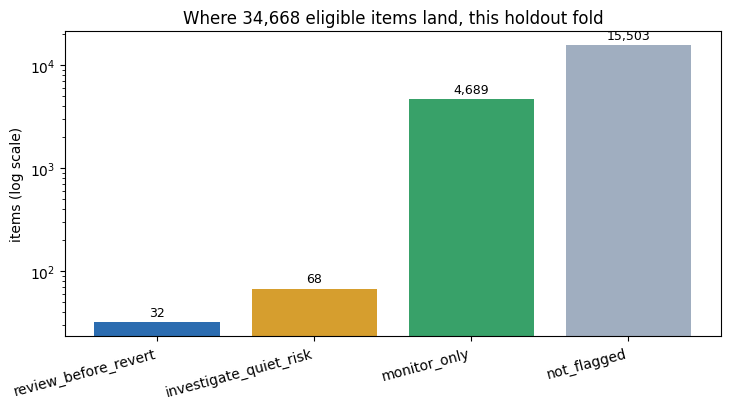

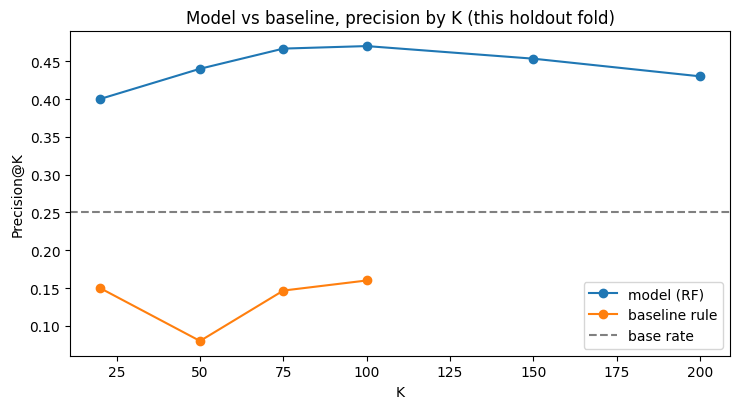

wrote work/figures/action_bands.png, precision_at_k.png, action_queue_metrics.json


In [14]:
import pathlib, json
import matplotlib.pyplot as plt

pathlib.Path("work/outputs").mkdir(parents=True, exist_ok=True)
pathlib.Path("work/figures").mkdir(parents=True, exist_ok=True)

output_cols = ["rank","content_hash_id","client_hash_id","rf_proba","is_declining","relative_gap",
               "band","reason_code","action","verify_first","expected_click_lift",
               "ctr_gap_pct","within_window_trend","impr_feat","pos_feat","feat_client_share","trend_pct"]
ranked[output_cols].to_csv("work/outputs/action_queue.csv", index=False)
print(f"wrote {len(ranked):,} ranked rows to work/outputs/action_queue.csv")

# figure 1: where the eligible population actually lands
band_order = ["review_before_revert","investigate_quiet_risk","monitor_only","not_flagged"]
counts = band_counts_full.reindex(band_order, fill_value=0)
fig, ax = plt.subplots(figsize=(7.5,4.2))
bars = ax.bar(range(len(counts)), counts.values, color=["#2b6cb0","#d69e2e","#38a169","#a0aec0"])
ax.set_yscale("log"); ax.set_xticks(range(len(counts))); ax.set_xticklabels(counts.index, rotation=15, ha="right")
ax.set_ylabel("items (log scale)"); ax.set_title(f"Where {len(shared):,} eligible items land, this holdout fold")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v*1.15, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("work/figures/action_bands.png", dpi=120); plt.show()

# figure 2: model vs baseline precision by K
fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.plot(list(pk.keys()), list(pk.values()), marker="o", label="model (RF)")
ax.plot(list(baseline_pk.keys()), list(baseline_pk.values()), marker="o", label="baseline rule")
ax.axhline(shared["is_declining"].mean(), color="gray", linestyle="--", label="base rate")
ax.set_xlabel("K"); ax.set_ylabel("Precision@K"); ax.legend()
ax.set_title("Model vs baseline, precision by K (this holdout fold)")
plt.tight_layout(); plt.savefig("work/figures/precision_at_k.png", dpi=120); plt.show()

metrics = {
    "population_size": int(len(shared)), "population_clients": int(shared["client_hash_id"].nunique()),
    "test_fold_size": int(len(te_df)), "test_fold_clients": int(te_df["client_hash_id"].nunique()),
    "relative_gap_threshold": round(float(THRESHOLD), 2), "base_rate": round(float(shared["is_declining"].mean()), 3),
    "rule_ctr_gap_q75_cut": round(float(GAP_Q75), 3), "rule_fire_rate": round(float(rule_fire_rate), 3),
    "verify_first_threshold_pct": VERIFY_THRESHOLD, "review_k": REVIEW_K,
    "precision_at_k_model": {k: round(v,3) for k,v in pk.items()},
    "precision_at_k_baseline": {k: round(v,3) for k,v in baseline_pk.items()},
    "band_counts_full": band_counts_full.to_dict(), "band_counts_top100": band_counts_top.to_dict(),
    "needs_data_check_top100": int(top100["verify_first"].sum()),
    "top_client_overrepresentation_x": round(float(top_client_n/100/pop_share), 1),
    "split_seed": 7, "rf_random_state": 42, "rf_n_jobs": 1,
}
with open("work/figures/action_queue_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("wrote work/figures/action_bands.png, precision_at_k.png, action_queue_metrics.json")


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.